In [ ]:
import cv2
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO
import mediapipe as mp

In [ ]:
model = YOLO('../yolov8n.pt')

In [ ]:
cap = cv2.VideoCapture("../data/input.mp4")

## Inspection of the video

In [4]:
fps    = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

In [5]:
print("FPS:",fps)

FPS: 25.0


In [6]:
print("Total frames:", frames)

Total frames: 8125


In [7]:
print("Width x Height:", width, height)

Width x Height: 1920 1080


## Displaying the Frames

In [8]:
def get_frame(cap, frame_no):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ret, frame = cap.read()
    if ret:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None

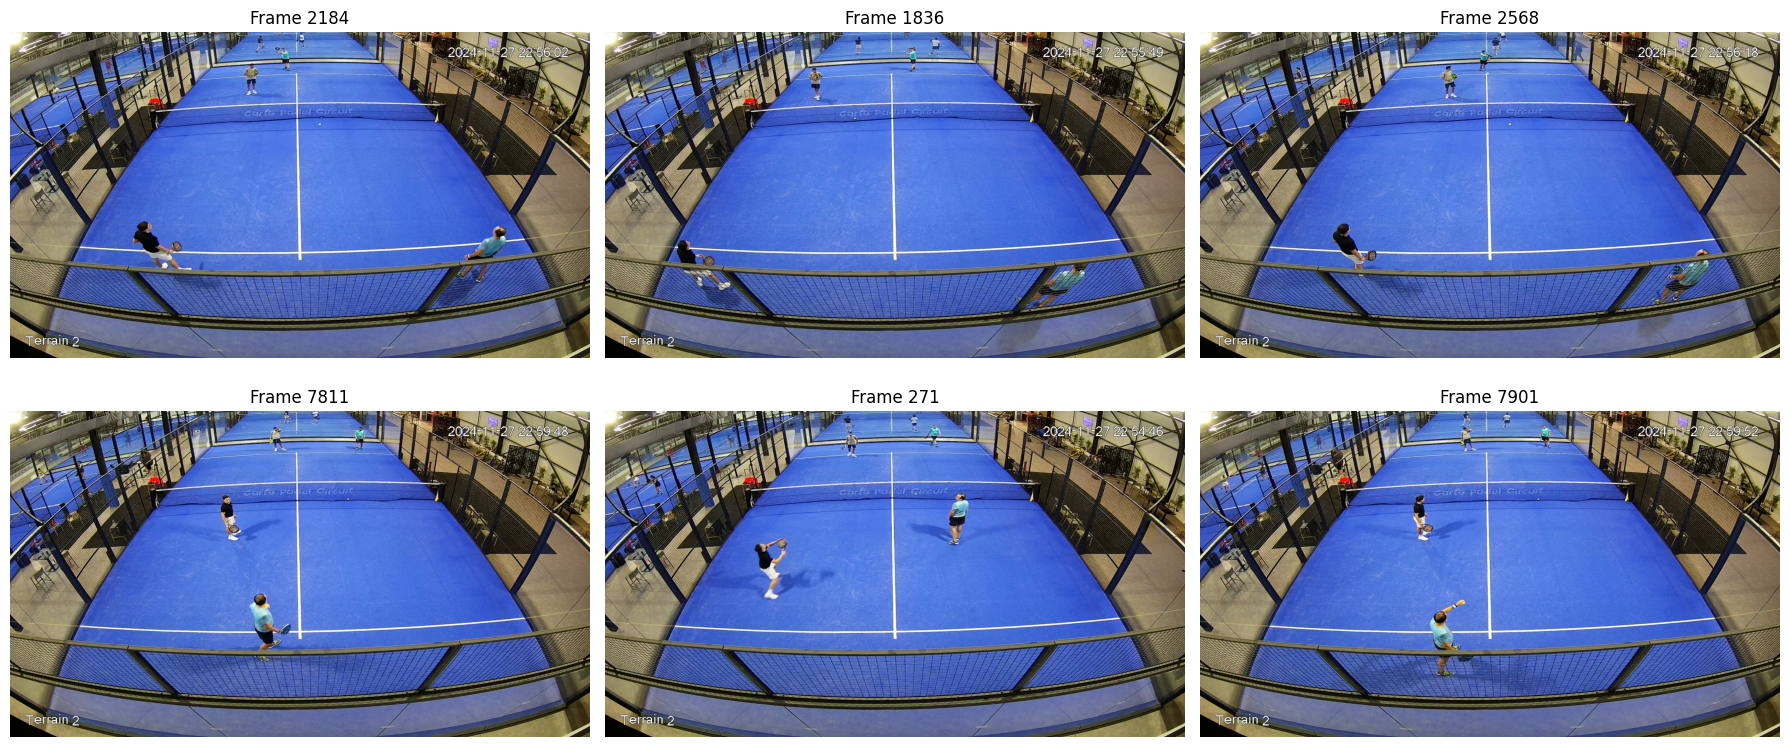

In [9]:
random_frames = random.sample(range(frames), 6)


fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, fn in zip(axes.flatten(), random_frames):
    frame = get_frame(cap, fn)
    ax.imshow(frame)
    ax.set_title(f"Frame {fn}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## Checking what YOLO finds on a single frame

In [10]:
test_frame = get_frame(cap, frames // 2)  # middle of video
results = model(test_frame, verbose=False)[0]

In [11]:
for box in results.boxes:
    cls_id  = int(box.cls)
    cls_name = model.names[cls_id]
    conf    = float(box.conf)
    print(f"Detected: {cls_name:20s} confidence: {conf:.2f}")

Detected: person               confidence: 0.52
Detected: person               confidence: 0.29
Detected: person               confidence: 0.27


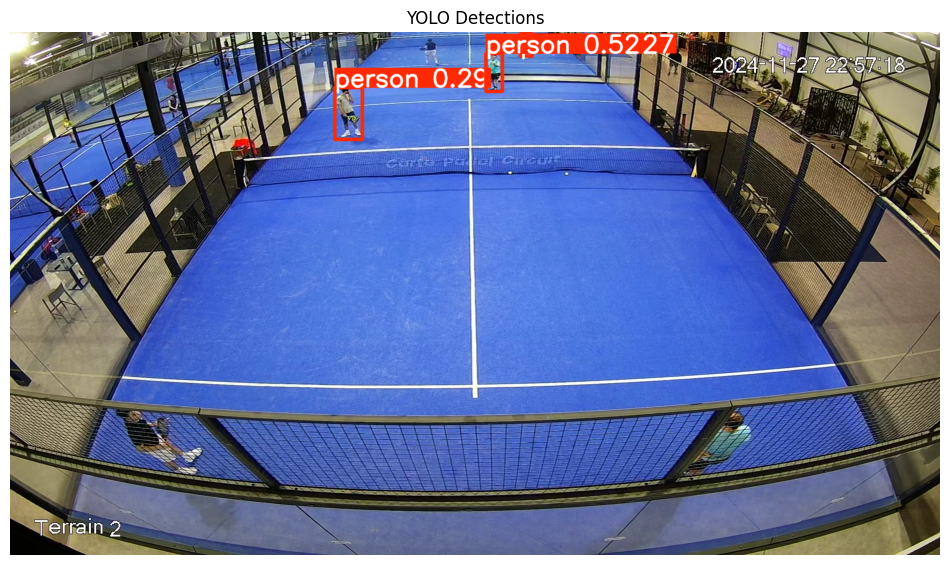

In [12]:
annotated = results.plot()
plt.figure(figsize=(12, 7))
plt.imshow(annotated)
plt.title("YOLO Detections")
plt.axis('off')
plt.show()

## Running Mediapipe on one player crop

In [13]:
mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose       = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

# grab a frame and get first person bounding box from YOLO
test_frame = get_frame(cap, frames // 2)
results    = model(test_frame, verbose=False)[0]

player_crop = None

Pose landmarks detected successfully!
Right wrist  — x:0.29  y:0.52
Right elbow  — x:0.34  y:0.42
Right shoulder — x:0.39  y:0.31


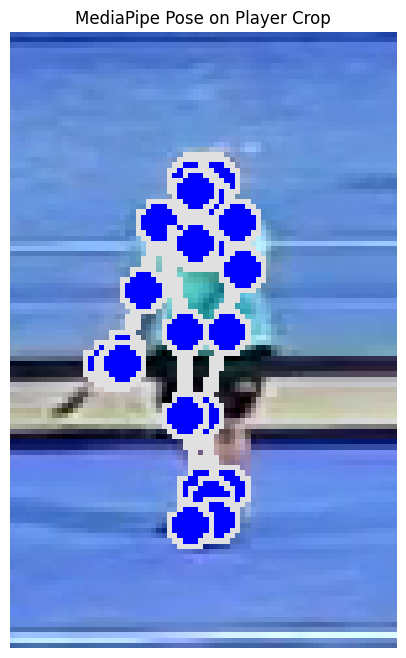

In [14]:
for box in results.boxes:
    if model.names[int(box.cls)] == 'person':
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        # add some padding
        pad = 20
        x1, y1 = max(0, x1-pad), max(0, y1-pad)
        x2, y2 = min(width, x2+pad), min(height, y2+pad)
        player_crop = test_frame[y1:y2, x1:x2]
        break

if player_crop is not None:
    pose_results = pose.process(player_crop)
    
    annotated_crop = player_crop.copy()
    if pose_results.pose_landmarks:
        mp_drawing.draw_landmarks(
            annotated_crop,
            pose_results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS
        )
        print("Pose landmarks detected successfully!")
        
        # print key joint positions
        lm = pose_results.pose_landmarks.landmark
        print(f"Right wrist  — x:{lm[mp_pose.PoseLandmark.RIGHT_WRIST].x:.2f}  y:{lm[mp_pose.PoseLandmark.RIGHT_WRIST].y:.2f}")
        print(f"Right elbow  — x:{lm[mp_pose.PoseLandmark.RIGHT_ELBOW].x:.2f}  y:{lm[mp_pose.PoseLandmark.RIGHT_ELBOW].y:.2f}")
        print(f"Right shoulder — x:{lm[mp_pose.PoseLandmark.RIGHT_SHOULDER].x:.2f}  y:{lm[mp_pose.PoseLandmark.RIGHT_SHOULDER].y:.2f}")
    else:
        print("No pose landmarks found on this crop — try a different frame")
    
    plt.figure(figsize=(6, 8))
    plt.imshow(annotated_crop)
    plt.title("MediaPipe Pose on Player Crop")
    plt.axis('off')
    plt.show()
else:
    print("No person detected in this frame — try a different frame number")
